# <center> Практика. Статистические тесты в контексте EDA

## Постановка задачи

HR-агентство изучает тренды на рынке труда в IT. Компания хочет провести исследование на основе данных о зарплатах в сфере Data Science за 2020–2022 годы и получить некоторые выводы.

Мы должны исследовать данные и сделать выводы по полученным результатам. Подкрепить свои рассуждения и выводы визуализациями и с помощью статистического тестирования проверить, являются ли выводы статистически значимыми.

Наша задача провести анализ, в процессе которого мы должны:
1. Выяснить, какие факторы влияют на зарплату специалиста Data Scientist.
2. Ответить на ключевые вопросы HR-агентства:
    * Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?
    * Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?
    * Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?
    * Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?

На каждый вопрос необходимо ответить с уровнем значимости $\alpha=0.05$.

В данной работе мы будем пользоваться данными HR-агенства о зарплатах в сфере Data Science с рядом характеристик

Данные содержат следующие столбцы:
 - ```work_year``` - год, в котором была выплачена зарплата
 - ```experience_level``` - опыт работы на этой должности в течение года со следующими возможными значениями:
    * EN — Entry-level/Junior;
    * MI — Mid-level/Intermediate;
    * SE — Senior-level/Expert;
    * EX — Executive-level/Director.
- ```employment_type``` - тип трудоустройства для этой роли:
    * PT — неполный рабочий день;
    * FT — полный рабочий день;
    * CT — контракт;
    * FL — фриланс.
- ```job_title``` - роль, в которой соискатель работал в течение года.
- ```salary``` - общая выплаченная валовая сумма заработной платы.
- ```salary_currency``` - валюта выплачиваемой заработной платы в виде кода валюты ISO 4217.
- ```salary_in_usd``` - зарплата в долларах США (валютный курс, делённый на среднее значение курса доллара США за соответствующий год через fxdata.foorilla.com).
- ```employee_residence``` - основная страна проживания сотрудника в течение рабочего года в виде кода страны ISO 3166.
- ```remote_ratio``` - общий объём работы, выполняемой удалённо. Возможные значения:
    * 0 — удалённой работы нет (менее 20 %);
    * 50 — частично удалённая работа;
    * 100 — полностью удалённая работа (более 80 %).
- ```company_location``` - страна главного офиса работодателя или филиала по контракту в виде кода страны ISO 3166.
- ```company_size``` - среднее количество людей, работавших в компании в течение года:
    * S — менее 50 сотрудников (небольшая компания);
    *  — от 50 до 250 сотрудников (средняя компания);
    * L — более 250 сотрудников (крупная компания).

Оригинальный датасет: [“Data Science Job Salaries” (kaggle.com)](https://www.kaggle.com/datasets/ruchi798/data-science-job-salaries)

## **1. Загрузка и обработка данных**

In [370]:
# загружаем необходимые библиотеки
import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
from statsmodels import stats as sms
import category_encoders as ce

import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots
# делаем визуальную настройку графиков
sns.set_theme("notebook") 
sns.set_palette("Set2") 

In [371]:
# загружаем датасет
data = pd.read_csv('data_hw/ds_salaries.csv')
data.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [372]:
# задаём уровень значимости
alpha = 0.05 
print("Уровень значимости alpha = {:.2f}".format(alpha))

Уровень значимости alpha = 0.05


### Проанализируем данные на информативность:

В датасете есть ряд неинформативных признаков, которые не будут участвовать в исследовании:
* столбец 'Unnamed: 0' - он дублирует индексы строк
* расчеты будем вести по столбцу "salary_in_usd" - в нем данные о зарплате уже приведены к единой валюте, соответственно:
    * столбец "salary" - зарплата в нацинальной валюте неактуальна
    * столбец "salary_currency" - национальная валюта, также не актуален

Удалим эти столбцы:

In [373]:
data = data.drop(['Unnamed: 0','salary','salary_currency'], axis = 1)

### Проверим данные на наличие полных дубликатов:

In [374]:
print('Количество дубликатов: {}'.format(data[data.duplicated()].shape[0]))

Количество дубликатов: 42


In [375]:
# Удаляем дубликаты:
data = data.drop_duplicates()
print('Размер таблицы после удаления дубликатов: {}'.format(data.shape))

Размер таблицы после удаления дубликатов: (565, 9)


### Проверим датасет на пропуски:

In [376]:
cols_null_percent = data.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

Series([], dtype: float64)

Пропусков в датасете нет

### Соответствуют ли типы данным значениям в столбцах:

In [377]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 565 entries, 0 to 606
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           565 non-null    int64 
 1   experience_level    565 non-null    object
 2   employment_type     565 non-null    object
 3   job_title           565 non-null    object
 4   salary_in_usd       565 non-null    int64 
 5   employee_residence  565 non-null    object
 6   remote_ratio        565 non-null    int64 
 7   company_location    565 non-null    object
 8   company_size        565 non-null    object
dtypes: int64(3), object(6)
memory usage: 44.1+ KB


Типы данных корректны и соответствуют описанию

### Классифицируем признаки:

В данных следующие признаки являются **количественными**:
1. work_year
2. salary_in_usd

В данных следующие признаки являются **категориальными**:
1. experience_level
2. employment_type
3. job_title
4. employee_residence
5. remote_ratio - **порядковый признак**
6. company_location
7. company_size - **порядковый признак**


### Найдем основные статистические характеристики для признаков:

In [378]:
# Проанализируем признак work_year
data['work_year'].value_counts()

work_year
2022    278
2021    215
2020     72
Name: count, dtype: int64

>**Вывод**: Заметен рост количества данных от 2020 к 2022 году, причем от 2020 к 2021 рост составляет 300%

In [379]:
# Проанализируем признак salary_in_usd
data['salary_in_usd'].describe()

count       565.000000
mean     110610.343363
std       72280.702792
min        2859.000000
25%       60757.000000
50%      100000.000000
75%      150000.000000
max      600000.000000
Name: salary_in_usd, dtype: float64

In [380]:
# давайте посмотрим, кто получает 600.000$
mask = data['salary_in_usd'] == 600000
data[mask]

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
252,2021,EX,FT,Principal Data Engineer,600000,US,100,US,L


Руководитель высшего звена/директор в большой компании с числом сотрудников более 250. Страна - США

>**Вывод**: Разброс зарплаты от 2.859$ до 600.000$. Медианное значение составляет 100.000$, среднее арифметическое - 110.610$

In [381]:
# Проанализируем признак experience_level
data['experience_level'].value_counts()

experience_level
SE    243
MI    208
EN     88
EX     26
Name: count, dtype: int64

>**Вывод**: Большего всего данных представлено о категории SE — Senior-level/Expert, далее о специалистах уровня MI — Mid-level/Intermediate, на 3 месте по количеству данных находятся специалисты уровня EN — Entry-level/Junior, ну и замыкает список EX — Executive-level/Director

In [382]:
# Проанализируем признак employment_type
data['employment_type'].value_counts(normalize = True)

employment_type
FT    0.966372
PT    0.017699
CT    0.008850
FL    0.007080
Name: proportion, dtype: float64

>**Вывод**: почти 97% типов трудоустройства - полный рабочий день, менее 2% данных - неполный рабочий день, менее 1% - контракт и фриланс

In [383]:
#Проанализируем признак job_title
print(f"Количество различных наименований вакансий - {data['job_title'].value_counts().count()}")
data['job_title'].value_counts()

Количество различных наименований вакансий - 50


job_title
Data Scientist                              130
Data Engineer                               121
Data Analyst                                 82
Machine Learning Engineer                    39
Research Scientist                           16
Data Science Manager                         12
Data Architect                               11
Big Data Engineer                             8
Machine Learning Scientist                    8
Principal Data Scientist                      7
AI Scientist                                  7
Data Science Consultant                       7
Director of Data Science                      7
Data Analytics Manager                        7
ML Engineer                                   6
Computer Vision Engineer                      6
BI Data Analyst                               6
Lead Data Engineer                            6
Data Engineering Manager                      5
Business Data Analyst                         5
Head of Data                  

> **Выводы**: роль, в которой соискатель работал в течение года - наименование вакансии. В таблице представлено 50 вакансий. Больше всего (130) - Data Scientist, 121 - Data Engineer, 82 - Data Analyst и так далее по убыванию

In [384]:
# Проанализируем страну проживания сотрудника employee_residence
data['employee_residence'].value_counts()

employee_residence
US    295
GB     43
IN     30
CA     27
DE     24
FR     18
ES     15
GR     12
JP      7
PT      6
BR      6
PK      6
NL      5
PL      4
IT      4
RU      4
AE      3
AT      3
VN      3
TR      3
AU      3
RO      2
BE      2
SG      2
SI      2
DK      2
HU      2
NG      2
MX      2
BO      1
MY      1
TN      1
IE      1
DZ      1
AR      1
CZ      1
JE      1
LU      1
PR      1
RS      1
EE      1
CL      1
HK      1
KE      1
MD      1
CO      1
IR      1
CN      1
MT      1
UA      1
IQ      1
HN      1
BG      1
HR      1
PH      1
NZ      1
CH      1
Name: count, dtype: int64

In [385]:
data['employee_residence'].value_counts().count()

57

> **Выводы**: больше 50% данных в таблице - 295 - сотрудники из США, 43 человека из Великобритании, 30 из Индии. И даже 4 человека из России. В датасете представлены сотрудники из 57 стран

In [386]:
# Проанализируем признак remote_ratio - какая часть работы выполняется удаленно
data['remote_ratio'].value_counts()

remote_ratio
100    346
0      121
50      98
Name: count, dtype: int64

>**Выводы**: 346 значений - удаленная работа (на 80%), 121 значение - удаленной работы менее 20%, 98 значений - частично удаленная работа (от 20% до 80%)

In [387]:
# Проанализируем страну работодателя company_location
data['company_location'].value_counts()

company_location
US    318
GB     46
CA     28
DE     27
IN     24
FR     15
ES     14
GR     10
JP      6
NL      4
AT      4
PT      4
PL      4
LU      3
PK      3
BR      3
AE      3
MX      3
AU      3
TR      3
DK      3
IT      2
CZ      2
SI      2
RU      2
CH      2
NG      2
CN      2
BE      2
VN      1
EE      1
AS      1
DZ      1
MY      1
MD      1
KE      1
SG      1
CO      1
IR      1
CL      1
MT      1
IL      1
UA      1
IQ      1
RO      1
HR      1
NZ      1
HU      1
HN      1
IE      1
Name: count, dtype: int64

In [388]:
mask = data['company_location'] == 'RU'
data[mask]

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
160,2021,EX,FT,Head of Data,230000,RU,50,RU,L
161,2021,EX,FT,Head of Data Science,85000,RU,0,RU,M


In [389]:
data['company_location'].value_counts().count()

50

Из РФ представлено 2 записи в таблице.

>**Выводы**: 319 компаний локализованиы в США, 46 в Великобритании, 28 в Канаде, 27 в Германии и далее по убывающей. Всего 50 стран

In [390]:
# Оценим величину компаний по количеству сотрудников company_size
data['company_size'].value_counts()

company_size
M    290
L    193
S     82
Name: count, dtype: int64

>**Выводы**: Больше всего в датасете представлено средних компаний - 290, больших -193 и небольших - 82

---

## **2. Разведывательный анализ данных**

#### 2.1 **Визуальный анализ данных**

Проведем визуальный анализ всех признаков в контексте влияния на зарплату

Распределение зарплат по всем специалистам

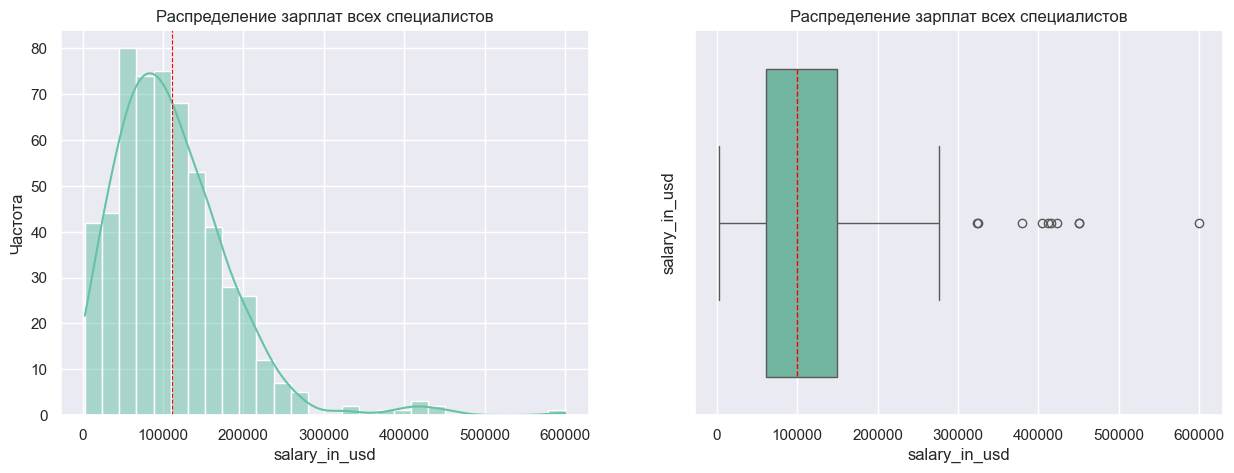

In [391]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['salary_in_usd'], kde=True, ax=axes[0])
axes[0].set(xlabel='salary_in_usd', ylabel='Частота')
axes[0].set_title('Распределение зарплат всех специалистов')
axes[0].axvline(data['salary_in_usd'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data['salary_in_usd'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(ylabel='salary_in_usd')
axes[1].set_title('Распределение зарплат всех специалистов')

plt.show()

In [392]:
data_agg = data['salary_in_usd'].describe().round(2).to_frame()
data_agg.columns = ['Распределение зарплат']
data_agg

,Распределение зарплат
count,565.00
mean,110610.34
std,72280.70
min,2859.00
25%,60757.00
50%,100000.00
75%,150000.00
max,600000.00


>**Выводы**: распределение зарплат олично от нормального. Имеются выбросы

---

Проанализируем зарплаты специалистов в зависимости от года

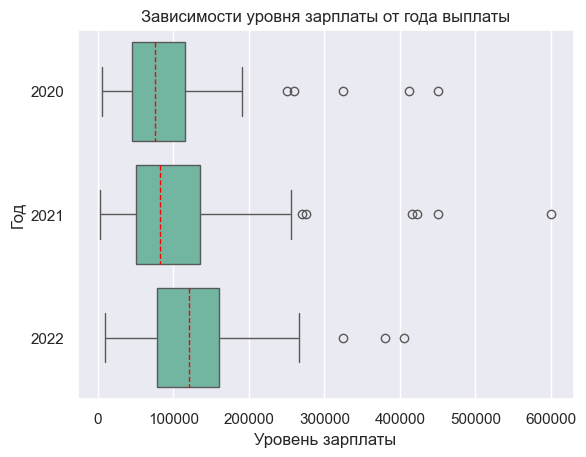

In [393]:
ax = sns.boxplot(data, x='salary_in_usd', y='work_year', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Уровень зарплаты', ylabel='Год')
plt.title('Зависимости уровня зарплаты от года выплаты')
plt.show()

>**Выводы**: на диаграмме заметно увеличение медианного уровня зарплаты, квартилей и максимального значения зарплаты от года к году. Нижний уровень зарплаты при этом остается на том же уровне. Является ли этот рост статистически значимым мы проверим статистическими тестами

---

Проанализируем зависимость уровня зарплаты от опыта работы на этой должности в течение года

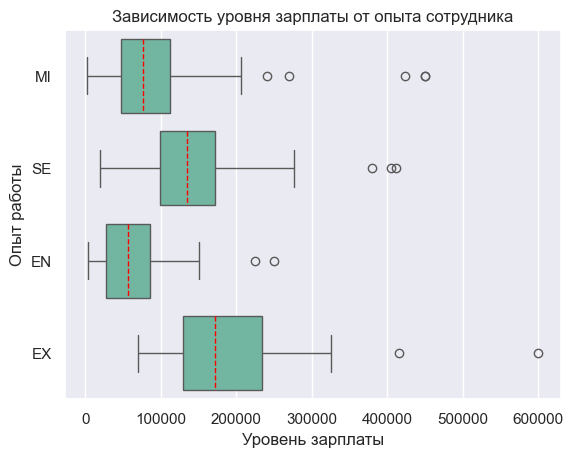

In [394]:
ax = sns.boxplot(data, x='salary_in_usd', y='experience_level', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Уровень зарплаты', ylabel='Опыт работы')
plt.title('Зависимость уровня зарплаты от опыта сотрудника')
plt.show()

>**Выводы:** Визуально мы можем однозначно заявить, что опыт работы вляет на зарплату в нашем датасете. Чем больше опыт работы на этой должности, тем выше зарплата. Достоверно подтвердим это утверждение статистическими способами

---

Проанализируем влияение типа трудоустройства на зарплату

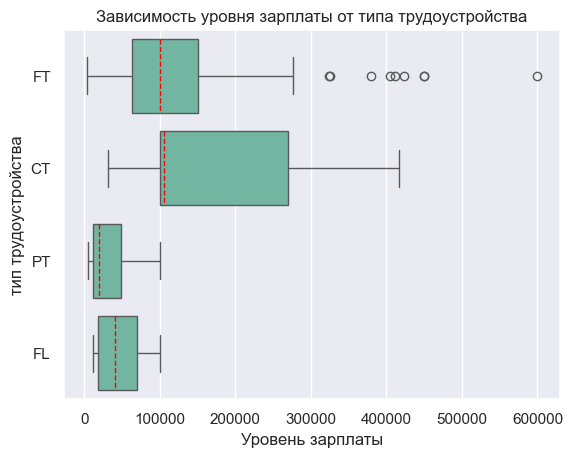

In [395]:
ax = sns.boxplot(data, x='salary_in_usd', y='employment_type', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Уровень зарплаты', ylabel='тип трудоустройства')
plt.title('Зависимость уровня зарплаты от типа трудоустройства')
plt.show()

>Выводы: уровень зарплаты зависит от типа трудоустройства. Медианное значение "Полный рабочий день" близко к медианному значению "контракт". Это нужно будет проверить статистическими методами

---

Давайте посмотрим на распределение зарплаты в зависимости от названия вакансии (Роль, в которой соискатель работал в течение года- job_title)

In [396]:
data_job_title = data.groupby(by='job_title')['salary_in_usd'].mean().sort_values(ascending=False).round().to_frame().reset_index()

In [397]:
fig = px.treemap(
    data_frame=data_job_title, #DataFrame
    path=['job_title'], #категориальный признак, для которого строится график
    values='salary_in_usd', #параметр, который сравнивается
    height=500, #высота
    width=1000, #ширина
    title='Распределение уровня ЗП в зависимости от должности' #заголовок
)

fig.show()

>Выводы: Уровень зарплаты зависит от должности

---

Рассмотрим, средние зарплаты в разрезе разных стран

In [398]:
data_employee_residence = data.groupby(by='employee_residence')['salary_in_usd'].mean().sort_values(ascending=False).round().to_frame().reset_index()
data_employee_residence

,employee_residence,salary_in_usd
0,MY,200000.0
1,PR,160000.0
2,US,150095.0
3,NZ,125000.0
4,CH,122346.0
5,AU,108043.0
6,RU,105750.0
7,SG,104176.0
8,JP,103538.0
9,AE,100000.0


In [399]:
fig = px.treemap(
    data_frame=data_employee_residence, #DataFrame
    path=['employee_residence'], #категориальный признак, для которого строится график
    values='salary_in_usd', #параметр, который сравнивается
    height=500, #высота
    width=1000, #ширина
    title='Средние зарплаты в разных странах' #заголовок
)

fig.show()

>Выводы: В этой выборке на 1 месте находится Малайзия, на 2 - Пуэрто-Рико, на 3 месте - США. Зависимость зарплаты от страны неоднозначна, так как нужно учитывать  количество вакансий и их разнообразие в той или иной стране, должности и т.п.

In [400]:
data[data['employee_residence'] == 'MY']

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
490,2022,SE,FT,Head of Data,200000,MY,100,US,M


In [401]:
data[data['employee_residence'] == 'PR']

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
265,2021,SE,FT,Lead Data Engineer,160000,PR,50,US,S


In [402]:
data[data['employee_residence'] == 'US']

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
4,2020,SE,FT,Machine Learning Engineer,150000,US,50,US,L
5,2020,EN,FT,Data Analyst,72000,US,100,US,L
6,2020,SE,FT,Lead Data Scientist,190000,US,100,US,S
8,2020,MI,FT,Business Data Analyst,135000,US,100,US,L
13,2020,MI,FT,Lead Data Analyst,87000,US,100,US,L
...,...,...,...,...,...,...,...,...,...
599,2022,MI,FT,Data Scientist,130000,US,100,US,M
602,2022,SE,FT,Data Engineer,154000,US,100,US,M
603,2022,SE,FT,Data Engineer,126000,US,100,US,M
604,2022,SE,FT,Data Analyst,129000,US,0,US,M


>В той же Малайзии и Пуэрто-Рико есть лишь по 1 сотруднику на должности руководителя проекта. И наоборот, в США вакансий 295, соответственно данные более репрезентативны

---

Посмотрим на взаимосвязь зарплаты и общего объёма работы, выполняемой удалённо. 

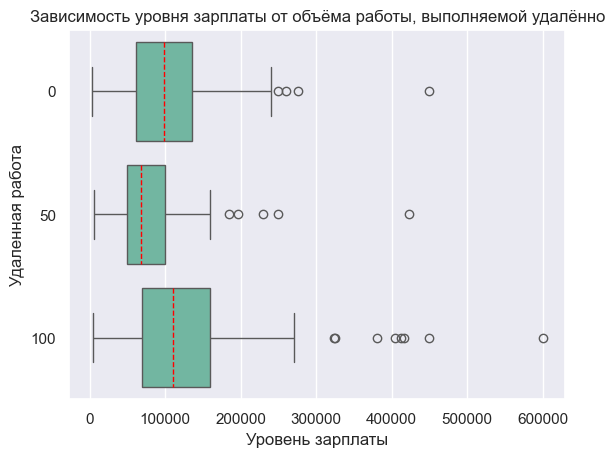

In [403]:
ax = sns.boxplot(data, x='salary_in_usd', y='remote_ratio', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Уровень зарплаты', ylabel='Удаленная работа')
plt.title('Зависимость уровня зарплаты от объёма работы, выполняемой удалённо')
plt.show()

>Выводы: распределение данных необходимо проверять статистическими методами. В частности признак 0 (удалённой работы нет (менее 20 %)) и признак 100 (полностью удалённая работа (более 80 %)) имеют близкую медиану и квартили

---

Влияние на зарплату Страны главного офиса работодателя или филиала по контракту 

In [404]:
data_company_location = data.groupby(by='company_location')['salary_in_usd'].mean().sort_values(ascending=False).round().to_frame().reset_index()
data_company_location

,company_location,salary_in_usd
0,RU,157500.0
1,US,144293.0
2,NZ,125000.0
3,IL,119059.0
4,JP,114127.0
5,AU,108043.0
6,CA,100122.0
7,AE,100000.0
8,DZ,100000.0
9,IQ,100000.0


In [405]:
fig = px.treemap(
    data_frame=data_company_location, #DataFrame
    path=['company_location'], #категориальный признак, для которого строится график
    values='salary_in_usd', #параметр, который сравнивается
    height=500, #высота
    width=1000, #ширина
    title='Средние зарплаты в странах главного офиса работодателя или филиала по контракту' #заголовок
)

fig.show()

>Выводы: данное распределение отличается от распределения средних зарплат в зависимости от места работы сотрудников. Влияет ли страна местоположения на зарплату неоднозначно. Нужно проверять статистическим тестом

---

Финальный визуальный анализ - влияние размера компании по количеству сотрудников на зарплату

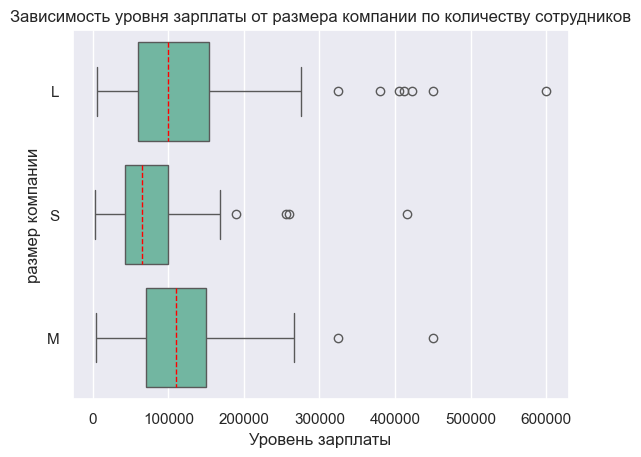

In [406]:
ax = sns.boxplot(data, x='salary_in_usd', y='company_size', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Уровень зарплаты', ylabel='размер компании')
plt.title('Зависимость уровня зарплаты от размера компании по количеству сотрудников')
plt.show()

>Выводы: конечно влияет. Сразу видно, что в маленьких компаниях медианный уровень зарплаты ниже чем в средних и больших. Также заметно, что медианный уровень средних и больших компаний примерно равен, как и уровни квартилей. Требуется проверка статистическим методом

---

Давайте визуализируем ответы на **ключевые вопросы HR-агентства**:


>1. Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?

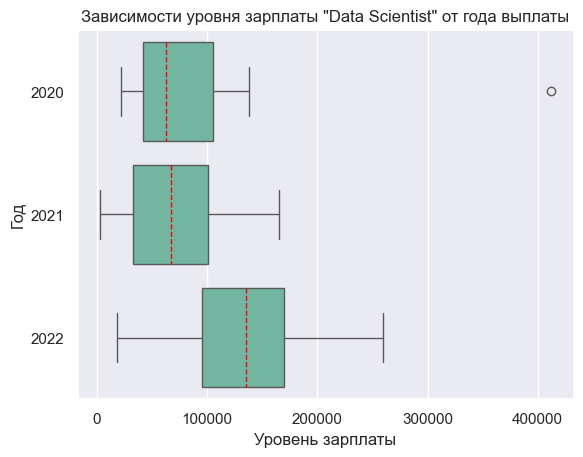

In [407]:
mask = data['job_title'] == 'Data Scientist'
data_1q = data[mask]

ax = sns.boxplot(data_1q, x='salary_in_usd', y='work_year', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Уровень зарплаты', ylabel='Год')
plt.title('Зависимости уровня зарплаты "Data Scientist" от года выплаты')
plt.show()

>**Вывод**: судя по графику, в 2020 году 75 квартиль был больше, чем он же в 2021. Поэтому однозначно ответить на вопрос "наблюдается ЕЖЕГОДНЫЙ рост зарплаты у ДС" нельзя. Необходимо провести статистические тесты

---

> 2. Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?

In [408]:
mask1 = data['job_title'] == 'Data Scientist'
mask2 = data['job_title'] == 'Data Engineer'
mask3 = data['work_year'] == 2022
data_2q = data[(mask1 | mask2) & mask3]

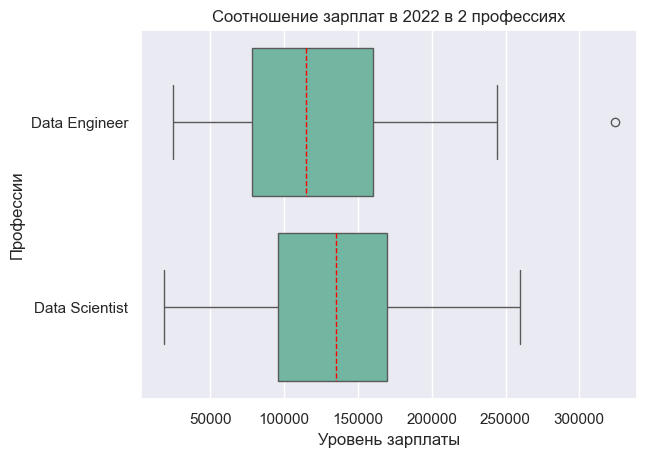

In [409]:
ax = sns.boxplot(data_2q, x='salary_in_usd', y='job_title', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Уровень зарплаты', ylabel='Профессии')
plt.title('Соотношение зарплат в 2022 в 2 профессиях')
plt.show()

>Вывод: Судя по графику, в 2022 году зарплата Data Scientist была выше, чем Data Engineer. Однако значения достаточно близки, чтобы потребовался статистический  тест

> 3. Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?

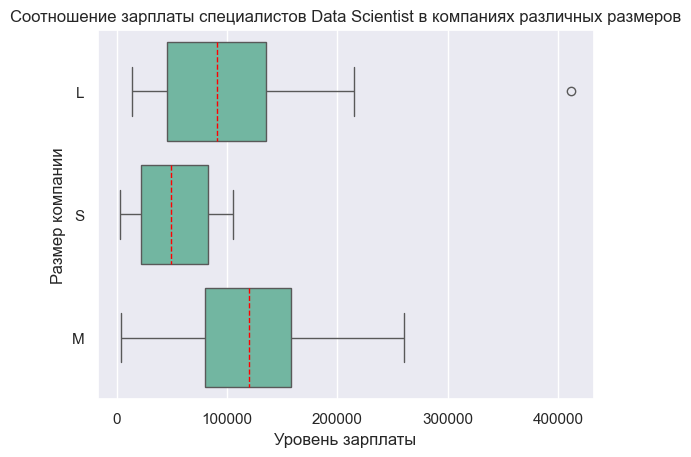

In [410]:
mask = data['job_title'] == 'Data Scientist'
data_3q = data[mask]

ax = sns.boxplot(data_3q, x='salary_in_usd', y='company_size', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Уровень зарплаты', ylabel='Размер компании')
plt.title('Соотношение зарплаты специалистов Data Scientist в компаниях различных размеров')
plt.show()

> Вывод: Как и в целом для датасета, так и для профессии Data Scientist наблюдается неоднозначность в зарплатах средних и больших компаний. Именно это требует статистического теста

> 4. Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?

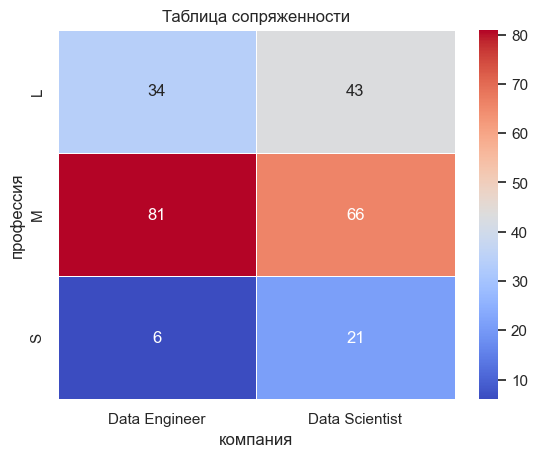

In [411]:
mask = (data['job_title'] == 'Data Scientist') | (data['job_title'] == 'Data Engineer')
data_4question =  data[mask]

cross_tab = pd.crosstab(index=data_4question['company_size'], columns=data_4question['job_title'])
ax = sns.heatmap(cross_tab, annot=True, linewidth=.5, fmt='.0f', cmap="coolwarm")
ax.set(xlabel='компания', ylabel='профессия')
plt.title('Таблица сопряженности')
plt.show()

 >Вывод: Согласно таблице сопряженности, данных профессий больше в компаниях размера М

---

>## **Общий вывод после визуального анализа**
1. при анализе роста зарплат с 2020 по 2020 наблюдался рост. Необходимо статистически подтвердить для всех данных этот рост
2. необходимо статистически подтвердить рост зарплаты в зависимости от роста Опыта
3. необходимо статистически подтвердить или опровергнуть, равно ли медианное значение зарплаты при формате работы Полный день и Контракт
4. необходимо статистическим методом подтвердить, что зарплата в разных странах одинакова или отличается
5. необходимо статистическим методом подтвердить, что зарплата на разных должностях отличается
6. Зависимость зарплаты и удаленной работы. Признак 0 (удалённой работы нет (менее 20 %)) и признак 100 (полностью удалённая работа (более 80 %)) имеют близкую медиану и квартили. Необходимо подтвердить их равенство
7. Влияет ли страна местоположения главного офиса или филиала на зарплату требует статистической проверки.
8. медианный уровень зарплат в средних и больших компаний примерно равен, как и уровни квартилей. Требуется проверка статистическим методом

---

#### 2.2 **Статистический анализ данных**

In [412]:
# функция для принятия решения о нормальности
def decision_normality(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Распределение отлично от нормального'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. Распределение является нормальным'.format(alpha))


# функция для принятия решения об отклонении нулевой гипотезы
def decision_hypothesis(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу в пользу альтернативной.'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))


>1. Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?

Разобьем эту задачу на 2 вопроса:
* Наблюдается ли рост зарплат у специалистов Data Scientistс в 2021 году по сравнению с 2020?
* Наблюдается ли рост зарплат у специалистов Data Scientistс в 2022 году по сравнению с 2021?

Подзадача №1

* **Нулевая гипотеза ($H_0$)** - зарплата в 2020 году($\mu_1$) была больше или равна зарплате в 2021 ($\mu_2$)
* **Альтернативная гипотеза ($H_1$)** - зарплата в 2020 году($\mu_1$) была меньше зарплаты в 2021 ($\mu_2$)
$$ H_0: \mu_1 \geq \mu_2 $$
$$ H_1: \mu_1 < \mu_2 $$



**ПРОВЕРКА НА НОРМАЛЬНОСТЬ**:

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально:
* *Нулевая гипотеза* ($H_0$): распределение данные является нормальным.
* *Альтернативная гипотеза* ($H_1$): распределение данных отлично от нормального.

In [413]:
mask1 = data['job_title'] == 'Data Scientist'
salary_ds = list(data[mask1]['salary_in_usd'])

# проводим тест Шапиро-Уилка
result = stats.shapiro(salary_ds)
decision_normality(result[1])

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


**ВЫБОР ТЕСТА**:
1. данные количественные
2. 2 группы данных
3. данные   независимы 
3. признак не распределен нормально

>Вывод - **U-критерий Манна — Уитни**

In [414]:
mask1 = data['job_title'] == 'Data Scientist'
mask2 = data['work_year'] == 2020
mask3 = data['work_year'] == 2021
mask4 = data['work_year'] == 2022
salary_ds_2020 = list(data[mask1&mask2]['salary_in_usd'])
salary_ds_2021 = list(data[mask1&mask3]['salary_in_usd'])
salary_ds_2022 = list(data[mask1&mask4]['salary_in_usd'])

In [415]:
# проводим тест
result = stats.mannwhitneyu(salary_ds_2020, salary_ds_2021)
decision_hypothesis(result[1])

p-value = 0.599
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


>**ВЫВОД:** Нет оснований отвергать нулевую гипотезу - зарплата в 2021 году была меньше, чем в 2020

Подзадача №2

* **Нулевая гипотеза ($H_0$)** - зарплата в 2021 году($\mu_1$) была больше или равна зарплате в 2022 ($\mu_2$)
* **Альтернативная гипотеза ($H_1$)** - зарплата в 2021 году($\mu_1$) была меньше зарплаты в 2022 ($\mu_2$)
$$ H_0: \mu_1 \geq \mu_2 $$
$$ H_1: \mu_1 < \mu_2 $$



Так как данные отличаются только годами, то критерий тот же

In [416]:
# проводим тест
result = stats.mannwhitneyu(salary_ds_2021, salary_ds_2022)
decision_hypothesis(result[1])

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


>**ВЫВОД:** Отвергаем нулевую гипотезу. Зарплата в 2022 году была больше, чем в 2021.

>Статистический тест подтвердил визуализацию. Зарплата у специалистов DS в 2021 году была меньше, чем в 2020. В 2022 больше, чем в 2021. Таким образом нельзя сказать, что наблюдается **ежегодный рост зарплат у специалистов Data Scientist**

---

> 2. Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году

**Согласно визуальному анализу в 2022 году зарплата Data Scientist **выше** зарплаты Data Engineer.**

Проверку на нормальность ЗП DS мы уже проводили. Проведем тест на нормальность ЗП DE:
* *Нулевая гипотеза* ($H_0$): распределение данные является нормальным.
* *Альтернативная гипотеза* ($H_1$): распределение данных отлично от нормального.

In [417]:
mask2 = data['job_title'] == 'Data Engineer'
salary_de = list(data[mask2]['salary_in_usd'])

# проводим тест Шапиро-Уилка
result = stats.shapiro(salary_de)
decision_normality(result[1])

p-value = 0.004
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


**ВЫБОР ТЕСТА**:
1. данные количественные
2. 2 группы данных
3. данные   независимы 
3. признак не распределен нормально

>Вывод - **U-критерий Манна — Уитни**

* **Нулевая гипотеза ($H_0$)** - зарплата DE в 2022 году($\mu_1$) была равна зарплате DS в 2022 ($\mu_2$)
* **Альтернативная гипотеза ($H_1$)** - зарплата DE ($\mu_1$) была не равна зарплаты DS ($\mu_2$)
$$ H_0: \mu_1 = \mu_2 $$
$$ H_1: \mu_1 \neq  \mu_2 $$



In [418]:
mask1 = data['job_title'] == 'Data Scientist'
mask2 = data['job_title'] == 'Data Engineer'
mask3 = data['work_year'] == 2022
salary_ds_2022 = list(data[mask1 & mask3]['salary_in_usd'])
salary_de_2022 = list(data[mask2 & mask3]['salary_in_usd'])

In [419]:
# проводим тест
result = stats.mannwhitneyu(salary_de_2022, salary_ds_2022, alternative='two-sided')
decision_hypothesis(result[1])

p-value = 0.319
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


>ВЫВОД: p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу. Статистически значимой разницы между зарплатами Data Engineer и Data Scientist в 2022 году не обнаружено

---

> 3. Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?

* **Нулевая гипотеза ($H_0$)** - зарплата DS в компании S ($\mu_1$) была равна зарплате в компании M ($\mu_2$) и была равна зарплате в компании L ($\mu_3$)
* **Альтернативная гипотеза ($H_1$)** - зарплата DS в компании S ($\mu_1$) была не равна зарплате в компании M ($\mu_2$) и была не равна зарплате в компании L ($\mu_3$)
$$ H_0: \mu_1 = \mu_2 = \mu_3 $$
$$ H_1: \mu_1 \neq  \mu_2 \neq  \mu_3 $$



**ВЫБОР ТЕСТА**:
1. данные количественные
2. 3 группы данных
3. данные   независимы 
3. признак не распределен нормально

>Вывод - **Критерий Краскела-Уоллиса**

In [420]:
mask1 = data['job_title'] == 'Data Scientist'
mask2 = data['company_size'] == 'S'
mask3 = data['company_size'] == 'M'
mask4 = data['company_size'] == 'L'

salary_ds_s = list(data[mask1 & mask2]['salary_in_usd'])
salary_ds_m = list(data[mask1 & mask3]['salary_in_usd'])
salary_ds_l = list(data[mask1 & mask4]['salary_in_usd'])

In [421]:
# проводим тест
result = stats.kruskal(salary_ds_s, salary_ds_m, salary_ds_l)
decision_hypothesis(result[1])



p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


>ВЫВОД: p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной. Зарплаты Data Scientist в компаниях разных размеров не равны. Статистический тест подтверждает визуальный анализ

---

> 4. Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?

*  **НУЛЕВАЯ ГИПОТЕЗА $H_0$**: между наличием должностей Data Scientist и Data Engineer и размером компании связи нет
*  **АЛЬТЕРНАТИВНАЯ ГИПОТЕЗА $H_1$**: между наличием должностей Data Scientist и Data Engineer и размером компании связь есть

ВЫБОР ТЕСТА:
1. Тип принзака "job_title"  - **категориальный**
2. Сколько сравниваемых групп? — Две.
3. Проверяется независимость групп? — Да.

Для проверки нашей гипотезы можно использовать критерий ${\chi}^2$ (хи-квадрат).

**Проведём тест**

In [422]:
# составляем таблицу сопряжённости
cross_table = pd.crosstab(data_4question['job_title'], data_4question['company_size'])

cross_table


company_size,L,M,S
job_title,,,
Data Engineer,34,81,6
Data Scientist,43,66,21


In [423]:
# проводим тест
_, p, _, _ = stats.chi2_contingency(cross_table)
decision_hypothesis(p)

p-value = 0.005
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


> Вывод: существует статистически значимая связь между наличием должностей Data Scientist и Data Engineer и размером компании

---

>Ответ на главный вопрос: **какие факторы влияют на зарплату специалиста Data Scientist**

In [437]:
df_encoded = pd.get_dummies(data, drop_first=True)  # кодирует все категориальные
corr_matrix = df_encoded.corr() # построение матрицы коррелиции
salary_corr = corr_matrix['salary_in_usd'].sort_values(ascending=False).nlargest(10) # вычленение информации по целевой переменной
print(salary_corr)

salary_in_usd                         1.000000
employee_residence_US                 0.571504
company_location_US                   0.529217
experience_level_SE                   0.333986
experience_level_EX                   0.270009
job_title_Principal Data Engineer     0.220272
job_title_Data Analytics Lead         0.171651
job_title_Principal Data Scientist    0.162278
work_year                             0.159326
job_title_Financial Data Analyst      0.135674
Name: salary_in_usd, dtype: float64


>Вывод: на зарплату влияет  страна проживания и работы - США, локация компании - США и 2 категории должности - SE — Senior-level/Expert и EX — Executive-level/Director

---

#### 2.3 **ДОПОЛНИТЕЛЬНЫЕ ИССЛЕДОВАНИЯ**

>2.3.1 Больше ли значение зарплаты при формате работы Контракт, чем Полный день?

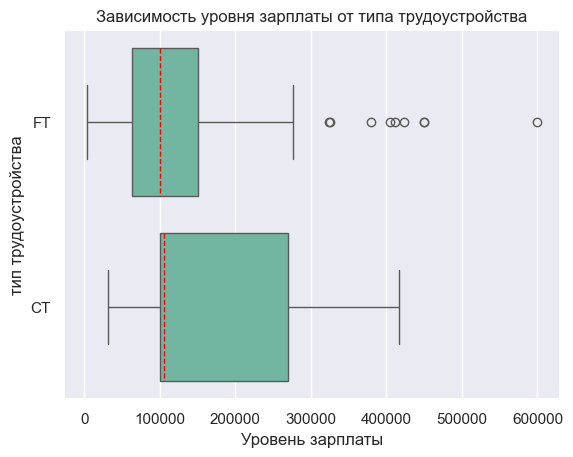

In [440]:
mask1 = data['employment_type'] == 'CT'
mask2 = data['employment_type'] == 'FT'
data_231 = data[mask1 | mask2]

ax = sns.boxplot(data_231, x='salary_in_usd', y='employment_type', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Уровень зарплаты', ylabel='тип трудоустройства')
plt.title('Зависимость уровня зарплаты от типа трудоустройства')
plt.show()

Судя по визуализации, медианные значения зарплат близки, однако основные значения распределения 'CT' выглядят выше, чем у 'FT'.

**Выбор статистического теста**:
1. данные количественные
2. 2 группы
3. группы независимы
4. не распределены по нормальному закону

**U-критерий Манна-Уитни**

* $\mu_1$ - зарплата при типе "Контракт"
* $\mu_2$ - зарплата при типе "Полный день"
$$H_0: \mu_1 <= \mu_2$$
$$H_1: \mu_1 > \mu_2$$

In [441]:
salary_CT = list(data[mask1]['salary_in_usd'])
salary_FT = list(data[mask2]['salary_in_usd'])
# проводим тест
result = stats.mannwhitneyu(salary_CT, salary_FT, alternative='greater')
decision_hypothesis(result[1])

p-value = 0.187
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


> Вывод: зарплата при типе трудоустройства Контракт меньше или равна зарплате при типе - Полный день.

При режиме Полный день заметно большое количество выбросов. Проведем дополнительное исследование медиан распределений с помощью метода Краскела — Уоллиса

* Нулевая гипотеза: Медианная зарплата при режиме Контракт равно медианной зарпате при режиме Контракт
* Альтернативная гипотеза: медианные зарплаты не равны

$$H_0: m_1 = m_2$$
$$H_1: m_1 \neq m_2$$

In [442]:
# проводим тест
result = stats.kruskal(salary_CT, salary_FT)
decision_hypothesis(result[1])

p-value = 0.373
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


>Вывод: У нас нет оснований утверждать, что Медианные значения зарплат при режиме "Полный день"  и "Контракт" отличаются

---

> 2.3.2 Необходимо подтвердить, что медианный уровень зарплат специалистов DS в средних и больших компаний примерно равен

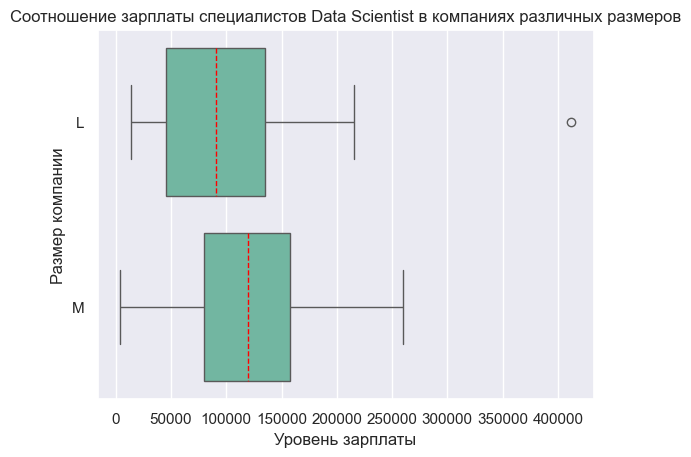

In [444]:
mask1 = data['job_title'] == 'Data Scientist'
mask2 = data['company_size'] == 'M'
mask3 = data['company_size'] == 'L'
data_232 = data[mask1 & (mask2|mask3)]

ax = sns.boxplot(data_232, x='salary_in_usd', y='company_size', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Уровень зарплаты', ylabel='Размер компании')
plt.title('Соотношение зарплаты специалистов Data Scientist в компаниях различных размеров')
plt.show()

* **Нулевая гипотеза** - медианные значения зарплат в компаниях M и L равны
* **Альтернативная гипотеза** - медианные значения зарплат в компаниях M и L не равны

$$H_0: M_m = M_l$$
$$H_1: M_m \neq M_l$$

**Выбор статистического теста**:
1. данные количественные
2. 2 группы
3. группы независимы
4. не распределены по нормальному закону

Однако в связи с наличием выброса и необходимостью ответить о равенстве медиан, воспользуюсь **критерием Краскела-Уоллиса**


In [447]:
salary_M = list(data[mask1 & mask2]['salary_in_usd'])
salary_L = list(data[mask1 & mask3]['salary_in_usd'])
# проводим тест
result = stats.kruskal(salary_CT, salary_FT)
decision_hypothesis(result[1])

p-value = 0.373
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


>Вывод: У нас нет оснований утверждать, что Медианные значения зарплат в компаниях уровня M и L отличаются

## **ОБЩИЙ ВЫВОД ПО ИССЛЕДОВАНИЮ**

1. На зарплату специалиста Data Scientist влияют следующие факторы: страна проживания и работы - США, локация компании - США и 2 категории должности - SE — Senior-level/Expert и EX — Executive-level/Director
2. Зарплата у специалистов DS в 2021 году была меньше, чем в 2020. В 2022 больше, чем в 2021. Таким образом нельзя сказать, что наблюдается **ежегодный рост зарплат у специалистов Data Scientist**
3. Статистически значимой разницы между зарплатами Data Engineer и Data Scientist в 2022 году не обнаружено
4. Зарплаты Data Scientist в компаниях разных размеров различаются. Статистический тест подтверждает визуальный анализ
5. существует статистически значимая связь между наличием должностей Data Scientist и Data Engineer и размером компании